In [1]:
import numpy as np
import matplotlib.pyplot as plt
import treescope as ts
import os
os.chdir("..")

In [2]:
def find_subsequence(one_hot, subsequence: str, char_list: str = "ACGTN"):
    masks = {k: one_hot[..., i].astype(bool) for i, k in enumerate(char_list)}
    masks["W"] = masks["A"] | masks["T"]
    matches = np.ones_like(one_hot[..., 0], dtype=bool)
    for i, char in enumerate(subsequence):
        matches &= np.roll(masks[char], -i, axis=-1)
    return matches

# def motif_correlation(one_hot1, one_hot2, motif:str="TATAWAW", onehot: str = "ACGTN"):
#     distr1 = find_subsequence(one_hot1, motif, onehot).mean(axis=0)
#     distr2 = find_subsequence(one_hot2, motif, onehot).mean(axis=0)
#     return corr(distr1, distr2) # questa riga non va

In [3]:
real = np.load("data/discdiff.npz")
real_data, real_labels = real["data"], real["labels"]
print(real_data.shape, real_labels.shape)

generated = np.load("generated/discdiff_L_test.npz")
generated_data, generated_labels = generated["data"], generated["labels"]

random_data = np.eye(5)[np.random.randint(0, 4, generated_data.shape[:-1])]

(159123, 2048, 5) (159123, 16)


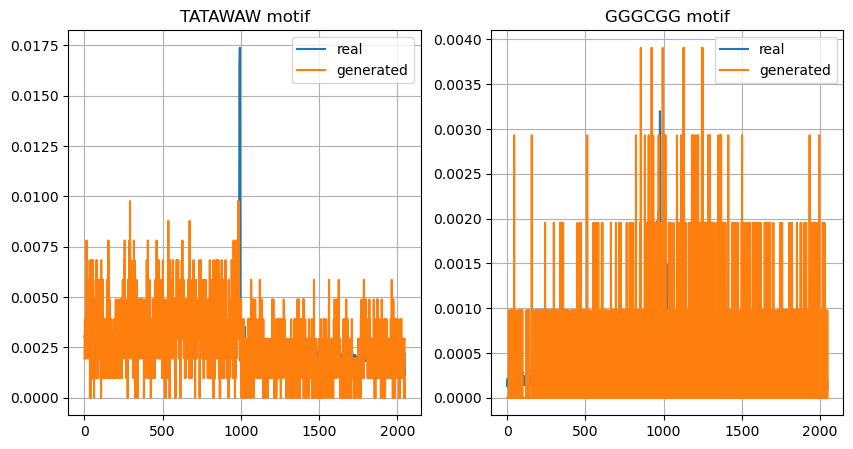

In [8]:
plt.figure(figsize=(10, 5))

plt.subplot(121)
plt.title("TATAWAW motif")
res_real = find_subsequence(real_data, "TATAWAW")
plt.plot(res_real.mean(axis=0), label="real")

res_generated = find_subsequence(generated_data, "TATAWAW")
plt.plot(res_generated.mean(axis=0), label="generated")

# res_random = find_subsequence(random_data, "TATAWAW")
# plt.plot(res_random.mean(axis=0), label="random")

plt.legend()
plt.grid()


plt.subplot(122)
plt.title("GGGCGG motif")
res_real = find_subsequence(real_data, "GGGCGG")
plt.plot(res_real.mean(axis=0), label="real")

res_generated = find_subsequence(generated_data, "GGGCGG")
plt.plot(res_generated.mean(axis=0), label="generated")

# res_random = find_subsequence(random_data, "GGGCGG")
# plt.plot(res_random.mean(axis=0), label="random")

plt.legend()
plt.grid()

plt.show()

100%|██████████| 15/15 [00:03<00:00,  4.45it/s]


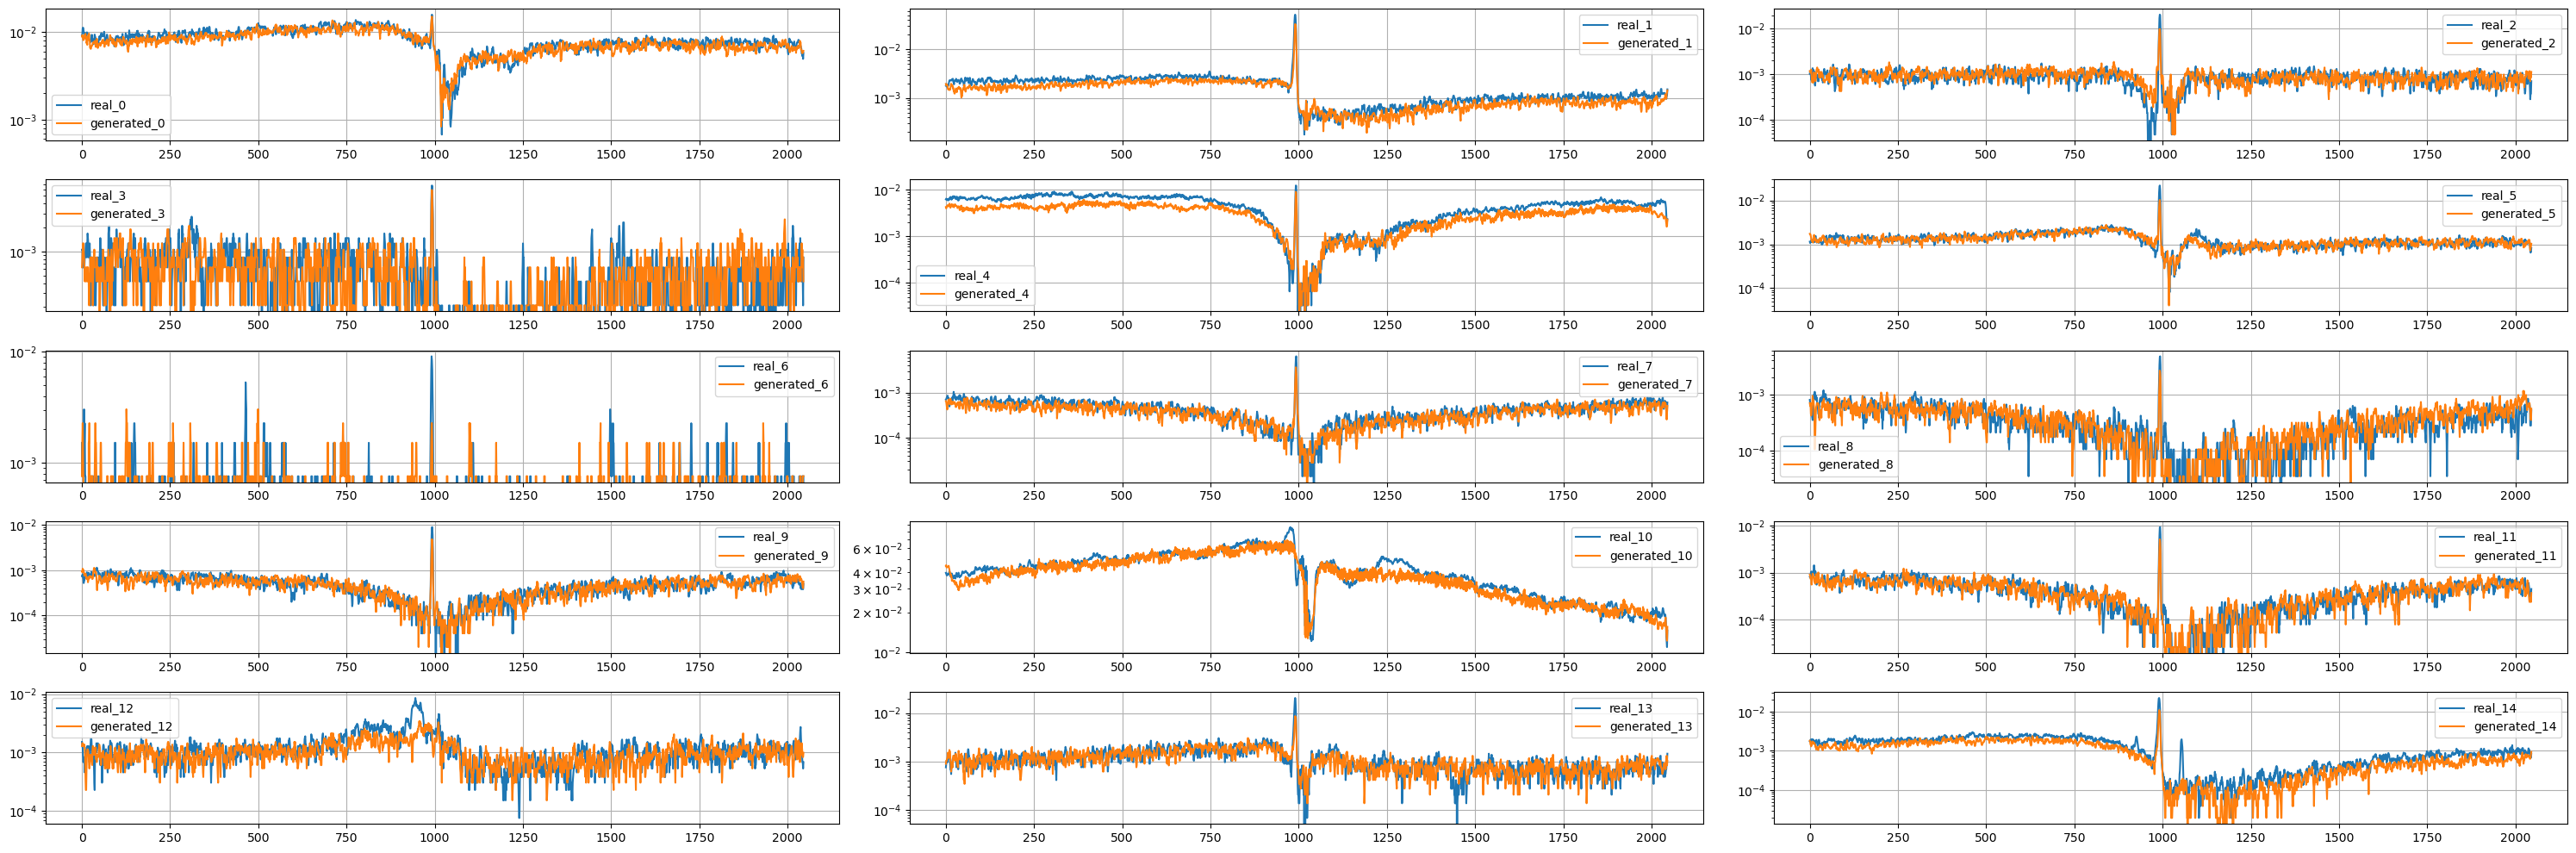

In [ ]:
from tqdm import tqdm   

def smooth(x, w=3):
    return np.convolve(x, np.ones(w), 'valid') / w

plt.figure(figsize=(30, 10))
for i in tqdm(range(15)):
    plt.subplot(5, 3, i+1)
    real_i = real_data[real_labels.argmax(-1) == i]
    res_real = find_subsequence(real_i, "TATAWAW")
    plt.semilogy(smooth(res_real.mean(axis=0)), label=f"real_{i}")

    generated_i = generated_data[generated_labels.argmax(-1) == i]
    res_generated = find_subsequence(generated_i, "TATAWAW")
    plt.semilogy(smooth(res_generated.mean(axis=0)), label=f"generated_{i}")

    # random_i = random_data[:len(generated_i)]
    # res_random = find_subsequence(random_i, "TATAWAW")
    # plt.semilogy(smooth(res_random.mean(axis=0)), label=f"random_{i}")

    # plt.title(f"{real_i.shape[0]} {generated_i.shape[0]}")
    # plt.ylim(0.0001, 0.001)
    plt.legend()
    plt.grid()
plt.tight_layout()
plt.savefig("figures/motif.pdf", bbox_inches="tight")
plt.show()